In [1]:
import pickle
with open('./Patient2/true_adt_data_scale.pickle', 'rb') as file:
    trueData = pickle.load(file)
# a is a list of 557 lists with 32 items each

In [2]:
import pickle
with open('./Patient2/predicted_adt_scale.pickle', 'rb') as file:
    predictedData = pickle.load(file)

In [3]:
# the files are in the format of 557 batches of 32 cells. Each cell has protein expression for 387 cells
print(len(trueData))          # number of batches: 557
print(len(trueData[0]))       # cells in the first batch: should be 32
print(len(trueData[0][0]))    # proteins per cell: should be 387
print(len(trueData[-1]))      # cells in the last batch: 32 or fewer

387
32
387
7


In [4]:
import numpy as np
true = np.concatenate([np.asarray(b, dtype=float).reshape(-1, 387) for b in trueData])
predicted = np.concatenate([np.asarray(a, dtype=float).reshape(-1, 387) for a in predictedData])
print(true.shape)   # 17805x387 (cells x proteins)
print(predicted.shape)

(12359, 387)
(12359, 387)


In [5]:
with open('csp_token_dict.pickle', 'rb') as file:   
    tokenDict = pickle.load(file)

proteinNames = sorted(tokenDict, key=tokenDict.get)   
print(proteinNames[:5])

['CD19', 'CD59', 'CD335', 'CD171', 'SCA1']


In [6]:
# removing proteins that were not predicted

measured = true.std(axis=0) > 0 #std of each column (protein) - if a protein does not vary, it was not predicted
print(measured.sum(), "proteins measured")
# 51 proteins remain
true2 = true[:, measured].copy()

predicted2 = predicted[:, measured].copy()
names2 = np.array(proteinNames)[measured]    
# print(names2[:5])
print(true2.shape, predicted2.shape, len(names2))   # (17805, 51) (17805, 51) 51

51 proteins measured
(12359, 51) (12359, 51) 51


In [7]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

rows = []
for i in range(true2.shape[1]):          # one loop per protein
    t = true2[:, i]                      # measured, all cells
    p = predicted2[:, i]                 # predicted, all cells

    r, _ = pearsonr(t, p)
    rho, _ = spearmanr(t, p)
    rmse = np.sqrt(np.mean((p - t) ** 2))

    rows.append({'protein': names2[i], 'pearson_r': r, 'spearman_rho': rho, 'rmse': rmse})

results = pd.DataFrame(rows).sort_values('pearson_r', ascending=False)
print(results.to_string(index=False))

protein  pearson_r  spearman_rho     rmse
    IgM   0.609505      0.587965 1.486136
    IgD   0.493455      0.454685 2.172202
  CD279   0.421821      0.393873 0.923728
  HLADR   0.341013      0.359145 1.419433
   CD21   0.321978      0.243350 2.126528
  CD152   0.318457      0.335112 0.949692
   CD22   0.303548      0.282323 2.403950
  CD223   0.284373      0.293917 0.963525
   CD38   0.272907      0.298229 0.977369
  CD124   0.267678      0.284128 1.032363
 CD45RO   0.254247      0.267547 1.014279
  CD278   0.253430      0.252547 1.010499
  CD138   0.239183      0.254383 0.997677
  CD185   0.231307      0.274326 1.439914
   CD88   0.225059      0.244985 0.994659
  CD274   0.221642      0.248287 0.975944
  CD197   0.217792      0.242564 1.078404
  CD314   0.217426      0.244784 0.996574
   CD14   0.216014      0.248271 0.999545
    IgG   0.200907      0.238131 1.010682
  CD268   0.192515      0.194258 2.212256
  CD184   0.185278      0.214394 1.035999
   CD32   0.182257      0.176055 1

IgD vs IgM (expect +): 0.11536267664903099
IgD vs CD27 (expect -): -0.018628879014926207


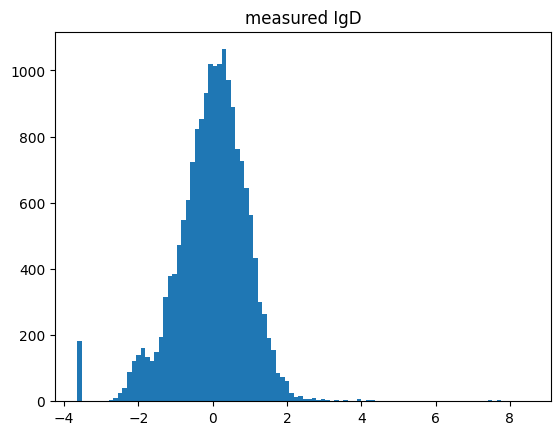

In [37]:
n = list(names2)
print("IgD vs IgM (expect +):", np.corrcoef(true2[:, n.index('IgD')], true2[:, n.index('IgM')])[0, 1])
print("IgD vs CD27 (expect -):", np.corrcoef(true2[:, n.index('IgD')], true2[:, n.index('CD27')])[0, 1])

import matplotlib.pyplot as plt
plt.hist(true2[:, n.index('IgD')], bins=100); plt.title('measured IgD'); plt.show()

In [38]:
import anndata as ad, scanpy as sc
rna = ad.read_h5ad('rna.h5ad')
print(rna.n_obs, "cells in rna.h5ad vs", true2.shape[0], "in CAPTAIN output")  # must match for this check

sc.pp.normalize_total(rna); sc.pp.log1p(rna)
for prot, gene in [('IgM', 'IGHM'), ('IgD', 'IGHD'), ('CD27', 'CD27'), ('CD20', 'MS4A1'), ('CD21', 'CR2')]:
    mrna = np.asarray(rna[:, gene].X.todense()).ravel()
    print(f"{prot}: baseline r = {np.corrcoef(true2[:, n.index(prot)], mrna)[0, 1]:.3f}")

17805 cells in rna.h5ad vs 17805 in CAPTAIN output
IgM: baseline r = 0.309
IgD: baseline r = 0.200
CD27: baseline r = -0.006
CD20: baseline r = 0.131
CD21: baseline r = 0.037


median ADT counts per cell: 719.0
B2M       87.619882
HLA-DR    48.814434
IgM       47.049874
CD279     36.491603
CD69      31.451222
CD5       23.923111
IgG       23.433867
CD80      23.142881
CD27      22.254591
CD21      22.247571
CD19      22.102106
CD32      22.048357
CD20      21.407301
CD124     19.558607
CD307d    19.146476
dtype: float64


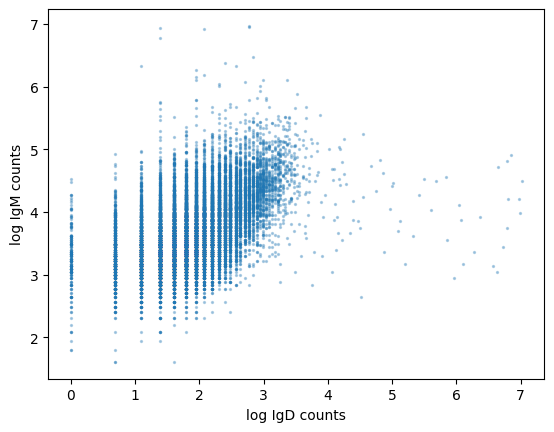

In [39]:
raw = ad.read_h5ad('protein.h5ad')
tot = np.asarray(raw.X.sum(axis=1)).ravel()
print("median ADT counts per cell:", np.median(tot))
print(pd.Series(np.asarray(raw.X.mean(axis=0)).ravel(), index=raw.var_names).sort_values(ascending=False).head(15))

igd = np.asarray(raw[:, 'IgD'].X.todense()).ravel()
igm = np.asarray(raw[:, 'IgM'].X.todense()).ravel()
plt.scatter(np.log1p(igd), np.log1p(igm), s=2, alpha=0.3)
plt.xlabel('log IgD counts'); plt.ylabel('log IgM counts'); plt.show()

In [40]:
p_saved = ad.read_h5ad("protein.h5ad")
r_saved = ad.read_h5ad("rna.h5ad")
print("same cells, same order:", (p_saved.obs_names == r_saved.obs_names).all())

for bc in p_saved.obs_names[:3]:
    orig = protein[bc, 'IgD'].X.toarray().ravel()[0]      # from the original matrix
    saved = p_saved[bc, 'IgD'].X.toarray().ravel()[0]     # from the saved file
    print(bc, orig, saved)                                  # the two numbers should match

same cells, same order: True


NameError: name 'protein' is not defined

In [22]:
#testing
t = [1,2,100]
p = [1,2,3]
r, pvalue = pearsonr(t,p)
pvalue

np.float64(0.3277362298828939)

In [44]:
import anndata as ad
import numpy as np
import pandas as pd

demo = ad.read_h5ad('pbmc_protein_test_demo.h5ad')
#mine = ad.read_h5ad('protein.h5ad')

mine = p_saved


def dense(a):
    return a.X.toarray() if hasattr(a.X, 'toarray') else np.asarray(a.X)

# ---- 1. overall counts per cell ----
for label, a in [('demo (all PBMCs)', demo), ('your B cells', mine)]:
    X = dense(a)
    tot = X.sum(axis=1)
    print(f"{label:18s} cells={a.n_obs:6d}  antibodies={a.n_vars:3d}  "
          f"median counts/cell={np.median(tot):7.0f}  per antibody={np.median(tot)/a.n_vars:5.1f}")

# ---- 2. demo B cells only ----
print("\ncell types in demo:", demo.obs['celltype.l1'].value_counts().to_dict())
demo_b = demo[demo.obs['celltype.l1'] == 'B'].copy()

# ---- 3. shared proteins, side by side (mean raw counts per cell) ----
shared = [p for p in mine.var_names if p in demo.var_names]
table = pd.DataFrame({
    'demo_all_cells': dense(demo[:, shared]).mean(axis=0),
    'demo_B_cells':   dense(demo_b[:, shared]).mean(axis=0) if demo_b.n_obs else np.nan,
    'your_B_cells':   dense(mine[:, shared]).mean(axis=0),
}, index=shared).round(1)
print(f"\n{len(shared)} proteins in both panels (mean raw counts per cell):")
print(table.sort_values('demo_B_cells', ascending=False).to_string())

# ---- 4. signal vs. background inside the demo ----
# how much brighter are B cell markers on demo B cells than on other cells?
demo_other = demo[demo.obs['celltype.l1'] != 'B']
for p in ['CD19', 'CD20', 'IgD', 'IgM', 'CD21', 'CD22']:
    if p in demo.var_names and demo_b.n_obs:
        on_b = dense(demo_b[:, p]).mean()
        off_b = dense(demo_other[:, p]).mean()
        print(f"demo {p:5s}: B cells {on_b:7.1f}  vs other cells {off_b:6.1f}  (ratio {on_b/(off_b+0.1):5.1f}x)")

demo (all PBMCs)   cells=   100  antibodies=224  median counts/cell=   4698  per antibody= 21.0
your B cells       cells= 17805  antibodies= 54  median counts/cell=    719  per antibody= 13.3

cell types in demo: {'Mono': 34, 'CD4 T': 24, 'CD8 T': 20, 'NK': 10, 'other T': 4, 'B': 3, 'other': 3, 'DC': 2}

37 proteins in both panels (mean raw counts per cell):
        demo_all_cells  demo_B_cells  your_B_cells
CD19         26.799999    400.299988          22.1
CD22         15.800000    237.699997          13.3
IgD           8.800000    211.300003           8.1
CD21          5.500000    116.300003          22.2
CD268         5.100000     61.000000          13.8
CD20          2.400000     38.700001          21.4
CD196        14.000000     35.299999           2.9
HLA-DR       13.700000     23.299999          48.8
CD45RA       14.800000     18.000000           5.3
CD27         43.599998     12.300000          22.3
IgM           2.700000     11.700000          47.0
CD16         32.000000     